# Introduction to Xarray and Visualise the IberFire datacube

This notebook is an **introductory tutorial on xarray**, the Python library designed for labelled N-dimensional data (datacubes). The **IberFire** datacube will be leveraged-a multi-dimensional dataset built for analysing fire-related variables across Spain. You can download the **IberFire** datacube [here](https://zenodo.org/records/15798999).

---

## What you’ll do

1. **Open the datacube** with `xarray.open_dataset` and inspect its structure (dimensions, coordinates, variables, attributes).  
2. **Slice & dice** the data: select specific variables, time ranges, spatial windows and vertical levels.  
3. **Visualise** the data.

---

#### Note

* The environment already defines `DATACUBE_PATH` in `src/config.py`. Make sure you have installed the project in *editable* mode (`pip install -e .`) so that `from src.config import DATACUBE_PATH` resolves correctly.


## 1 — Open the datacube & take a first look 🔍

The IberFire datacube is stored as a NetCDF file, which *xarray* can open in a single line.

After opening it, you will see the following:

| Element          | Meaning                                                                        |
| ---------------- | ------------------------------------------------------------------------------ |
| `Dimensions`     | Named axes and their length (e.g. `y: 920, x: 1188, time: 6241`) |
| `Coordinates`    | 1-D arrays that label each dimension (x/y coordinate values and time stamps)     |
| `Data variables` | Actual variables (temperature, FWI, etc.) each as an `xarray.DataArray`  |
| `Attributes`     | Dataset-level metadata such as creation date and licence                       |


In [1]:
from src.config import DATACUBE_PATH
import xarray as xr

ds = xr.open_dataset(DATACUBE_PATH)
ds

2025-07-03 16:41:34.192 | INFO     | src.config:<module>:13 - PROJ_ROOT path is: C:\Workspace\Projects\GAIA\Repos\IberFire


<xarray.Dataset> Size: 731GB
Dimensions:                                        (y: 920, x: 1188, time: 6241)
Coordinates:
  * x                                              (x) float64 10kB 2.675e+06...
  * y                                              (y) float64 7kB 2.492e+06 ...
  * time                                           (time) datetime64[ns] 50kB ...
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB ...
    y_index                                        (y, x) uint16 2MB ...
    is_spain                                       (y, x) uint16 2MB ...
    is_fire                                        (time, y, x) uint8 7GB ...
    is_near_fire                                   (time, y, x) uint8 7GB ...
    x_coordinate                                   (y, x) float32 4MB ...
    ...                                             ...
    LST                                            (time, y, x) float32 27GB ...
    SWI_001                                        (time, y, x) float32 27GB ...
    SWI_005                                        (time, y, x) float32 27GB ...
    SWI_010                                        (time, y, x) float32 27GB ...
    SWI_020                                        (time, y, x) float32 27GB ...
    FWI                                            (time, y, x) float32 27GB ...
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

#### Note:
We see that some features are spatial-only: they have (y,x) dimensions, without the time (t) dimension.

Other features are spatio-temporal: (time,y,x) dimensions.

**However**, some features that have low updating frequency (**Corine Land Cover** and **popdens**), are stored as spatial-only features to avoid storing repeated data. When extracting data from **IberFire**, if a cell from 2019-10-10 is selected for example, the correct versions of **Corine Land Cover** and **popdens** should be selected; i.e., CLC_2018 and popdens_2019.

## 2 — Select variables and slice the dataset ✂️  

The real power of **xarray** is the ability to grab just the piece of data you need with readable syntax.  
In this section we’ll practise some common selection patterns:

| Goal | xarray method(s) |
|------|------------------|
| A. Pick one or more **variables** | attribute access `ds.var`, key access `ds['var']` |
| B. Pick a single **spatial cell** (nearest coordinates) | `.sel(x=…, y=…, method='nearest')` |
| C. Pick exact **timestamps** | `.sel(time='YYYY-MM-DD')` or a list of dates |
| D. Pick **slices / windows** across any dimension | `.sel(dim=slice(start, stop))`, `.isel(dim=slice(i, j))` |
| E. Pick data that meet a **condition** | `.where(condition)` |

Below are minimal examples you can run directly.

---

### 2 A Select variables  



In [2]:
fwi = ds['FWI']
fwi

<xarray.DataArray 'FWI' (time: 6241, y: 920, x: 1188)> Size: 27GB
[6821163360 values with dtype=float32]
Coordinates:
  * x        (x) float64 10kB 2.675e+06 2.676e+06 ... 3.861e+06 3.862e+06
  * y        (y) float64 7kB 2.492e+06 2.491e+06 ... 1.574e+06 1.573e+06
  * time     (time) datetime64[ns] 50kB 2007-12-01 2007-12-02 ... 2024-12-31
Attributes:
    long_name:    Fire Weather Index
    description:  The Canadian Forest Fire Weather Index at 0.25 degree spati...
    source:       https://ewds.climate.copernicus.eu/datasets/cems-fire-histo...
    units:        dimensionless

In [3]:
# Several variables (Dataset)
subset = ds[['t2m_mean', 'RH_mean', "is_spain"]]
subset

<xarray.Dataset> Size: 55GB
Dimensions:   (time: 6241, y: 920, x: 1188)
Coordinates:
  * x         (x) float64 10kB 2.675e+06 2.676e+06 ... 3.861e+06 3.862e+06
  * y         (y) float64 7kB 2.492e+06 2.491e+06 ... 1.574e+06 1.573e+06
  * time      (time) datetime64[ns] 50kB 2007-12-01 2007-12-02 ... 2024-12-31
Data variables:
    t2m_mean  (time, y, x) float32 27GB ...
    RH_mean   (time, y, x) float32 27GB ...
    is_spain  (y, x) uint16 2MB ...
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

### 2 B Select a single spatial cell (nearest neighbour) and get the values of a feature

In [4]:
# With coordinates:
x_coord, y_coord = 3e+06, 2e06
cell = ds.sel(x=x_coord, y=y_coord, method='nearest')

print(f"Index of the x coordinate: {cell["x_index"].values}")
print(f"Index of the y coordinate: {cell["y_index"].values}")

cell["FWI"].values

Index of the x coordinate: 325
Index of the y coordinate: 492


array([4.625    , 3.2460938, 4.2773438, ..., 3.9570312, 3.9101562,
       4.3632812], dtype=float32)

*Note:* With method='nearest' you get the grid cell closest to the given coordinates.
Omit method if you want an exact match and know the coords are present.

In [5]:
# With indexes:
x_idx, y_idx = 325, 492
cell = ds.isel(x=x_idx, y=y_idx)
cell["FWI"].values

array([4.625    , 3.2460938, 4.2773438, ..., 3.9570312, 3.9101562,
       4.3632812], dtype=float32)

### 2 C Select exact timestamps

In [6]:
# A single day
day = ds.sel(time='2023-08-15')

# Several arbitrary dates
days = ds.sel(time=['2022-07-01', '2022-07-15', '2022-08-01'])

In [7]:
day

<xarray.Dataset> Size: 1GB
Dimensions:                                        (y: 920, x: 1188)
Coordinates:
  * x                                              (x) float64 10kB 2.675e+06...
  * y                                              (y) float64 7kB 2.492e+06 ...
    time                                           datetime64[ns] 8B 2023-08-15
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB ...
    y_index                                        (y, x) uint16 2MB ...
    is_spain                                       (y, x) uint16 2MB ...
    is_fire                                        (y, x) uint8 1MB ...
    is_near_fire                                   (y, x) uint8 1MB ...
    x_coordinate                                   (y, x) float32 4MB ...
    ...                                             ...
    LST                                            (y, x) float32 4MB ...
    SWI_001                                        (y, x) float32 4MB ...
    SWI_005                                        (y, x) float32 4MB ...
    SWI_010                                        (y, x) float32 4MB ...
    SWI_020                                        (y, x) float32 4MB ...
    FWI                                            (y, x) float32 4MB ...
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

In [8]:
days

<xarray.Dataset> Size: 1GB
Dimensions:                                        (y: 920, x: 1188, time: 3)
Coordinates:
  * x                                              (x) float64 10kB 2.675e+06...
  * y                                              (y) float64 7kB 2.492e+06 ...
  * time                                           (time) datetime64[ns] 24B ...
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB ...
    y_index                                        (y, x) uint16 2MB ...
    is_spain                                       (y, x) uint16 2MB ...
    is_fire                                        (time, y, x) uint8 3MB ...
    is_near_fire                                   (time, y, x) uint8 3MB ...
    x_coordinate                                   (y, x) float32 4MB ...
    ...                                             ...
    LST                                            (time, y, x) float32 13MB ...
    SWI_001                                        (time, y, x) float32 13MB ...
    SWI_005                                        (time, y, x) float32 13MB ...
    SWI_010                                        (time, y, x) float32 13MB ...
    SWI_020                                        (time, y, x) float32 13MB ...
    FWI                                            (time, y, x) float32 13MB ...
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

### 2 D Select slices / windows

In [9]:
summer_2022 = ds.sel(time=slice('2022-06-01', '2022-08-31'))

In [10]:
north_of_spain = ds.isel(y=slice(0,200))

### 2 E Conditional selection with `.where`

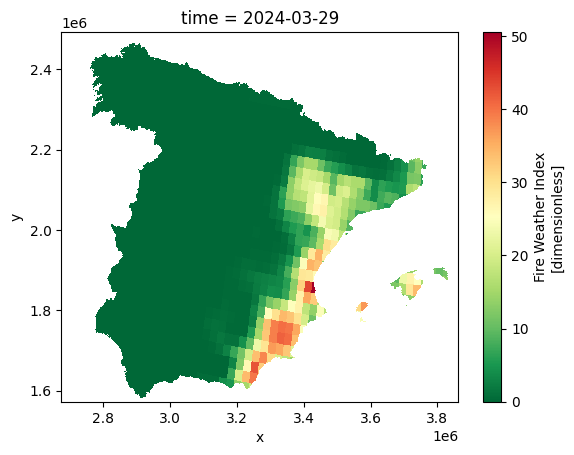

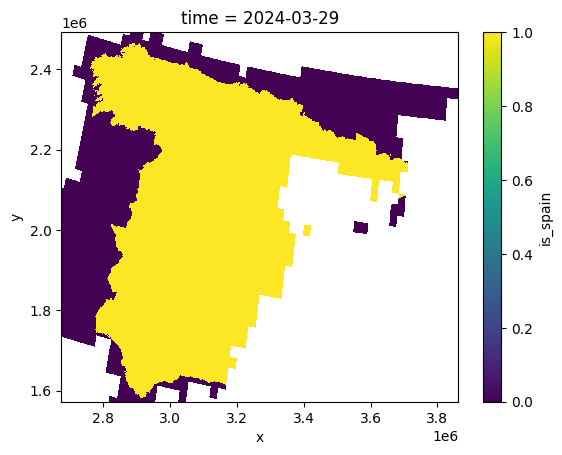

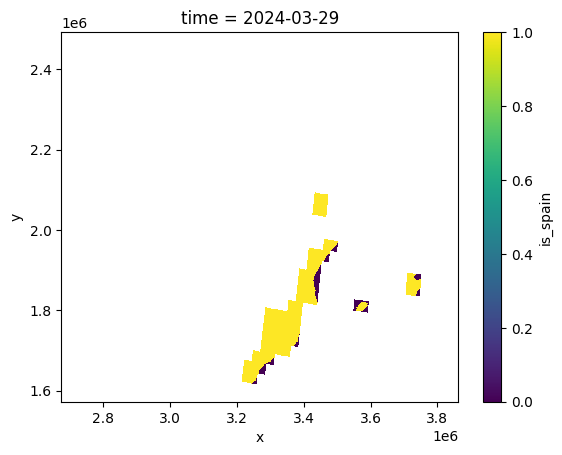

In [11]:
import matplotlib.pyplot as plt
fwi = ds["FWI"].sel(time="2024-03-29")

low_risk_is_spain = ds.sel(time="2024-03-29")["is_spain"].where(fwi < 5)
high_risk_is_spain = ds.sel(time="2024-03-29")["is_spain"].where(fwi > 25)

fwi.where(ds["is_spain"]==1).plot(cmap="RdYlGn_r")
plt.show()

low_risk_is_spain.plot()
plt.show()

high_risk_is_spain.plot()
plt.show()

## 3 — Visualise 📊

The quickest way to see any 2-D field in a datacube is just one line of code:

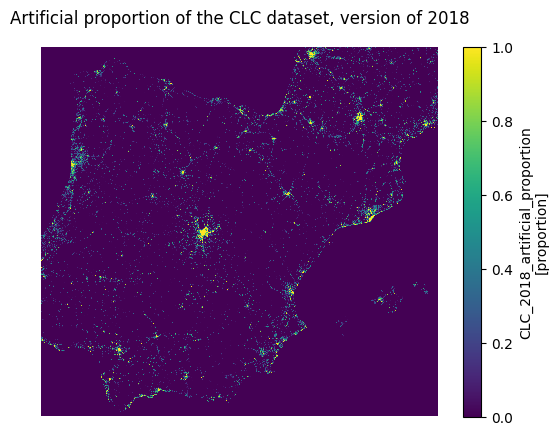

In [35]:
ds["CLC_2018_artificial_proportion"].plot()
plt.title("Artificial proportion of the CLC dataset, version of 2018")
plt.axis("off")
plt.show()

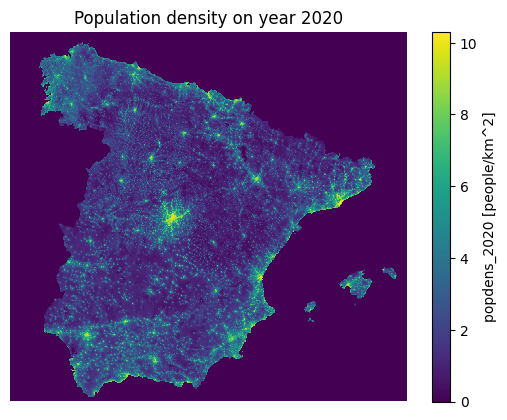

In [34]:
import numpy as np

np.log1p(ds["popdens_2020"]).plot()
plt.title("Population density on year 2020")
plt.axis("off")
plt.show()